<a href="https://colab.research.google.com/github/christy5165/Denoising_Autoencoder.ipynb/blob/main/GAN-WK-7C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training GAN for 2D Circle Points...
Epoch 0 | Gen Loss: 0.6387
Epoch 500 | Gen Loss: 0.6450
Epoch 1000 | Gen Loss: 0.7399
Epoch 1500 | Gen Loss: 0.7358
Training Complete!



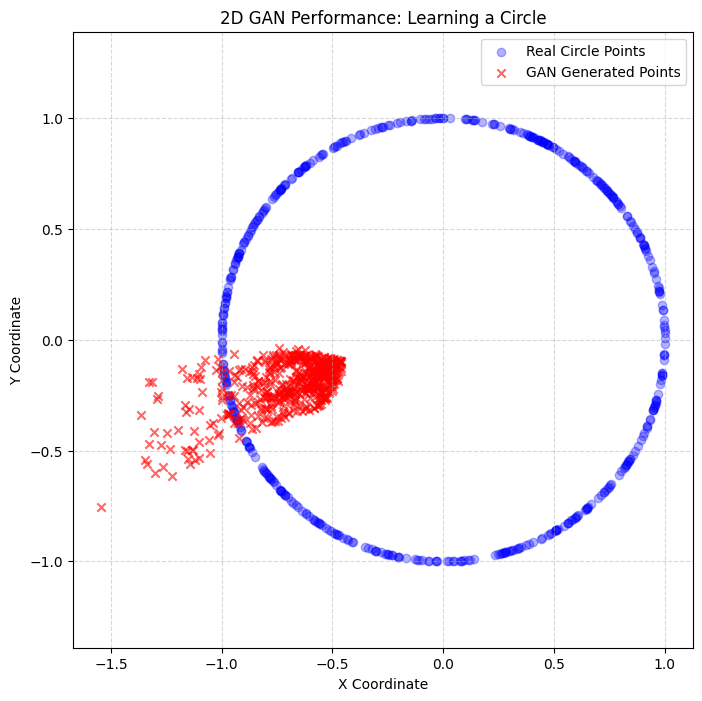

First 5 Generated 2D Points (x, y):
[[-0.6897519  -0.17582105]
 [-0.8415239  -0.09110263]
 [-0.7675426  -0.25688884]
 [-1.012591   -0.42142898]
 [-0.52227587 -0.26158652]]


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. SETUP THE REAL DATA (Points along a Circle)
# ---------------------------------------------------------
def get_real_data(n=1000):
    # Creating a synthetic circle with radius 1
    theta = torch.rand(n, 1) * 2 * np.pi
    x = torch.cos(theta)
    y = torch.sin(theta)
    return torch.cat((x, y), dim=1)

# ---------------------------------------------------------
# 2. DEFINE THE GAN MODELS (2D VERSION)
# ---------------------------------------------------------

# The Generator: Learns to create (x, y) coordinates
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 2) # Outputs two values: x and y
        )
    def forward(self, x):
        return self.model(x)

# The Discriminator: Judges if the (x, y) point is on the circle
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)

# Initialize models
generator = Generator()
discriminator = Discriminator()

# Settings
criterion = nn.BCELoss()
gen_optimizer = optim.Adam(generator.parameters(), lr=0.001)
disc_optimizer = optim.Adam(discriminator.parameters(), lr=0.001)

# ---------------------------------------------------------
# 3. THE TRAINING LOOP
# ---------------------------------------------------------
epochs = 2000
batch_size = 64

print("Training GAN for 2D Circle Points...")

for epoch in range(epochs):
    # --- Train Discriminator ---
    real_data = get_real_data(batch_size)
    noise = torch.randn(batch_size, 2)
    fake_data = generator(noise).detach()

    loss_d = criterion(discriminator(real_data), torch.ones(batch_size, 1)) + \
             criterion(discriminator(fake_data), torch.zeros(batch_size, 1))

    disc_optimizer.zero_grad()
    loss_d.backward()
    disc_optimizer.step()

    # --- Train Generator ---
    noise = torch.randn(batch_size, 2)
    fake_data = generator(noise)
    loss_g = criterion(discriminator(fake_data), torch.ones(batch_size, 1))

    gen_optimizer.zero_grad()
    loss_g.backward()
    gen_optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Gen Loss: {loss_g.item():.4f}")

print("Training Complete!\n")

# ---------------------------------------------------------
# 4. PLOT GENERATED VS REAL DATA
# ---------------------------------------------------------
with torch.no_grad():
    real_samples = get_real_data(500).numpy()
    fake_samples = generator(torch.randn(500, 2)).numpy()

plt.figure(figsize=(8, 8))
plt.scatter(real_samples[:, 0], real_samples[:, 1], color='blue', alpha=0.3, label='Real Circle Points')
plt.scatter(fake_samples[:, 0], fake_samples[:, 1], color='red', marker='x', alpha=0.6, label='GAN Generated Points')
plt.title("2D GAN Performance: Learning a Circle")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.axis('equal') # Keeps the circle from looking like an oval
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Show a few coordinates as requested
print("First 5 Generated 2D Points (x, y):")
print(fake_samples[:5])